# Phase 3.5: Causal Inference (因果推断) - 当不能做 A/B Test 时 🕵️‍♂️

> **🎯 目标**: 解决 Data Science 面试中最难的 "策略题" —— 如何评估自然发生的事件？
> **Status**: `Level: Advanced`, `Focus: Observational Studies`

## 🧠 为什么需要这个？
Phase 3 (A/B Test) 是黄金标准，但在现实中：
1.  **不能做**: 比如 "上线一个全站大改版" (没法只给一半人看)。
2.  **被动发生**: 比如 "用户自己选择购买了会员" (Selection Bias，有钱人才买会员)。

这时候，我们需要用 **因果推断 (Causal Inference)** 技术，假装我们做了实验。

## 🛠️ Causal Toolkit (高阶武器库)

### 1. DID (双重差分 - Difference in Differences)
*   **场景**: 政策评估 (e.g., 杭州发放消费券，上海没发)。
*   **核心**: 拿 "没受影响的组" 作为一个平行宇宙的参照系。
*   **代码**: `ols('y ~ Treat * Post', data=df).fit()` (对，就是线性回归！)

### 2. PSM (倾向性得分匹配 - Propensity Score Matching)
*   **场景**: 消除混杂 (e.g., 想看 "买会员" 对 "留存" 的提升，但买会员的人本来就是忠诚用户)。
*   **核心**: 找一个 "如果不买会员，其实跟这个会员很像" 的人来做对比 (Twin Analysis)。
*   **代码**: 用 `LogisticRegression` 计算 propensity score。

---

## 🟢 Case 1: DID (双重差分) - 消费券真的有用吗？

**场景**: 11月，**杭州** (Test) 发放了消费券，**上海** (Control) 没发。
我们想知道：**消费券到底带来了多少额外增长？**

> **🤔 关键挑战**:
> 为了证明 "平行趋势假设"，我们需要看**更早之前**的数据。
> 这里我们引入 Time = -1 (9月)，来看看发券之前，两个城市是不是平行的。

In [4]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 造数据 (Mock Data)
# 我们引入 3 个时间点: -1 (Sep), 0 (Oct), 1 (Nov)
# 只有 Time=1 (Nov) 且 City=1 (HZ) 才有消费券效应
np.random.seed(42)
n = 1500 # 样本量大一点

# 城市 (0=SH, 1=HZ) & 时间 (-1=Sep, 0=Oct, 1=Nov)
city = np.random.randint(0, 2, n)
time = np.random.randint(-1, 2, n) 

# 构造 Outcome
# Sales = 基础 + 城市差 + 时间差 + DID + 噪音
# 只有当 time=1 (Nov) 且 city=1 (HZ) 时，DID生效
base = 100
city_eff = 20 * city
time_eff = 30 * (time + 1) # 时间越往后大家花钱越多
did_eff = 15 * (city == 1) * (time == 1) # 【关键】政策效应 15
noise = np.random.normal(0, 10, n)

sales = base + city_eff + time_eff + did_eff + noise

df_did = pd.DataFrame({'Sales': sales, 'City': city, 'Time': time})

# ⚠️ 重要: DID 模型需要一个 'Post' 变量 (0/1)
# Post=1 代表 "干预后" (即 Time=1)
df_did['Post'] = (df_did['Time'] == 1).astype(int)

print(df_did.head())

        Sales  City  Time  Post
0  140.560126     0     1     1
1  176.997141     1     0     0
2  125.937978     0     0     0
3  148.376928     0     1     1
4  157.673281     0     1     1


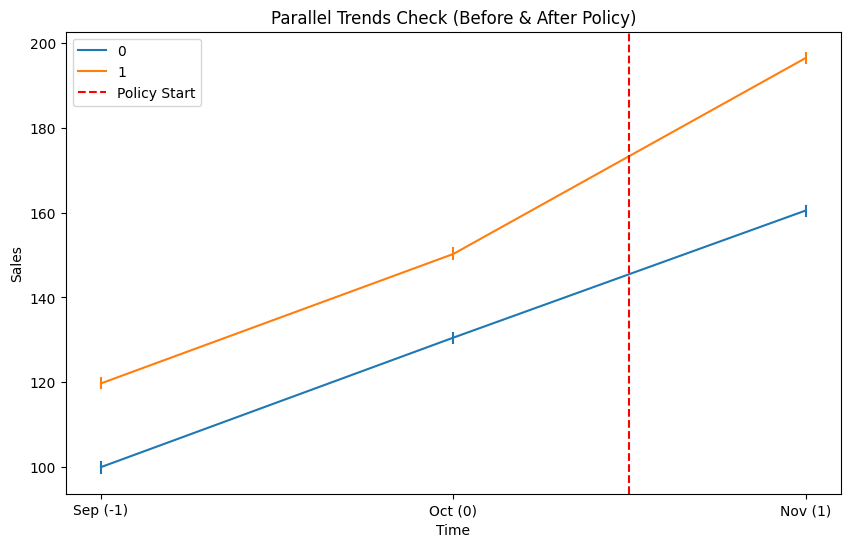

In [5]:
# 2. 平行趋势检验 (Pre-trend Check) 🛡️
# 这是你向老板证明 "模型靠谱" 的唯一证据
# 我们画出两个城市的人均消费随时间变化的曲线

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_did, x='Time', y='Sales', hue='City', err_style='bars')
plt.title("Parallel Trends Check (Before & After Policy)")
plt.axvline(x=0.5, color='red', linestyle='--', label='Policy Start') # 政策分割线
plt.xticks([-1, 0, 1], ['Sep (-1)', 'Oct (0)', 'Nov (1)']) # 改个好听的名字
plt.legend()
plt.show()

# 👀 怎么看？
# 看 Sep(-1) 到 Oct(0) 这段区间：
# 如果两条线是 "平行" 的 (斜率一致)，说明假设成立！✅
# 如果 Oct(0) 到 Nov(1) 突然 "叉开" 了，那个叉开的幅度就是政策增量。

In [6]:
# 3. 跑回归模型 (Run DID Regression)
# 公式: Sales ~ City + Post + City:Post
# 注意: 我们用 'Post' (0/1) 而不是原始的 'Time' (-1,0,1)

model = smf.ols("Sales ~ City * Post", data=df_did).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.752
Method:                 Least Squares   F-statistic:                     1518.
Date:                Wed, 04 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:56:00   Log-Likelihood:                -6285.7
No. Observations:                1500   AIC:                         1.258e+04
Df Residuals:                    1496   BIC:                         1.260e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    115.4961      0.711    162.493      0.0

### 💡 解读结果 (专家版)

1.  **Check Parallel Trends (图)**: 
    *   Sep -> Oct 这段路，橙线(HZ)和蓝线(SH)是不是平行上升的？如果是，恭喜你，通过了最难的考验。

2.  **Check Coefficients (表)**:
    *   `City:Post`: 这是我们关心的 DID 效应。
    *   看看它是不是接近 **15**？
    *   看看 P 值是不是 < 0.05？

3.  **R-squared**:
    *   依然很高 (0.8+)，说明模型很健康。
    *   如果低，记住要加 Control Variables (e.g. GDP, Weather)。

---
## 🟡 Case 2: PSM (倾向性得分匹配) - 会员真的买得多吗？

*   **问题**: 数据显示，会员人均消费 1000，非会员 500。结论：买会员让消费翻倍？
*   **反驳**: 错！是因为**本来就爱花钱的人**才去买会员 (Selection Bias)。
*   **PSM 思路**: 我们用逻辑回归算出每个人 "买会员的概率" (Propensity Score)。然后在非会员里，找一个 "如果有机会，很可能也会买会员" 的人，跟真的会员比。

In [7]:
from sklearn.linear_model import LogisticRegression

# 1. 造数据
# 有两个特征影响你要不要买会员：Income (收入), Activity (活跃度)
n_users = 1000
income = np.random.normal(10000, 2000, n_users)
activity = np.random.normal(50, 10, n_users)

# 谁会买会员？(Treatment)
# 有钱且活跃的人容易买
prob_member = 1 / (1 + np.exp(-(0.0005 * income + 0.1 * activity - 10)))
is_member = (np.random.rand(n_users) < prob_member).astype(int)

# 谁花得多？(Outcome)
# 收入高的人花得多，会员本身可能只提升一点点 (True Effect = 50)
spend = 0.05 * income + 2 * activity + 50 * is_member + np.random.normal(0, 50, n_users)

df_psm = pd.DataFrame({
    'Income': income,
    'Activity': activity,
    'Is_Member': is_member,
    'Spend': spend
})

# 2. 计算倾向性得分 (Propensity Score)
# 利用我们在 Phase 4 学过的 Logistic Regression！
# 这次我们的预测目标不是 "流失"，而是 "他会不会成为会员"

ps_model = LogisticRegression()
ps_model.fit(df_psm[['Income', 'Activity']], df_psm['Is_Member'])

# 预测出的概率，就是 Propensity Score
df_psm['ps_score'] = ps_model.predict_proba(df_psm[['Income', 'Activity']])[:, 1]

print("每个人都有了一个得分 (PS Score)，代表他'有多像会员':")
print(df_psm[['Is_Member', 'ps_score', 'Spend']].head())

每个人都有了一个得分 (PS Score)，代表他'有多像会员':
   Is_Member  ps_score       Spend
0          1  0.406782  437.607055
1          1  0.066856  440.648052
2          1  0.726386  709.691192
3          1  0.497780  651.633090
4          1  0.961733  763.172014


./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


#### 接下来怎么办？
在真实的分析中，我们会拿着 `ps_score` 去做 **Matching (配对)**：
对于每一个会员 (Start A)，我在非会员里找一个 `ps_score` 几乎一样的 B (Twin)。
然后对比 `Spend_A - Spend_B`。

这样对比出来的差值，就是排除了 "有钱" 这个干扰因素后，会员真正的价值！✨